# Exploratory Data Analysis of Equity Market Volatility
The aim of this notebook is to see if volatility clusters and persists. I want to investigate the properties of SPY returns and volatility, verify volatility clustering and motivate the need for volatility forecasting models which I will use later.

## Introduction 
Volatility is one of the most important quantities in quantitative finance.

It affects:

- Portfolio construction
- Risk management
- Options pricing
- Value at Risk calculations
- Derivatives trading
- Position sizing

Unlike stock prices themselves, volatility exhibits strong persistence and predictable patterns.

The objective of this notebook is to investigate the empirical properties of market returns using SPY and VIX data from 2005 onwards.

This particular notebook aims to answer the following questions:

1. What are the statistical properties of equity returns?
2. Do financial returns follow a normal distribution?
3. Does volatility cluster through time?
4. Is volatility persistent?
5. How closely does implied volatility track realized volatility?

The answers to these questions motivate the forecasting models developed in subsequent notebooks.

Let me do some basic imports I'll need

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf

from scipy.stats import kurtosis
from scipy.stats import skew

plt.style.use("ggplot")

START = "2005-01-01"

now lets load the data

In [3]:
spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

vix = yf.download(
    "^VIX",
    start=START,
    auto_adjust=True
)

spy.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2005-01-03,81.383720,82.371419,81.113117,82.236115,55748000
2005-01-04,80.389244,81.546069,80.125407,81.491947,69167600
2005-01-05,79.834511,80.673377,79.827744,80.328358,65667300
2005-01-06,80.240417,80.605732,80.003641,80.125413,47814700
2005-01-07,80.125420,80.659860,79.915699,80.483967,55847700


and construct returns

In [4]:
spy["returns"] = np.log(
    spy["Close"] / spy["Close"].shift(1)
)

spy = spy.dropna()

spy.head()

Price,Close,High,Low,Open,Volume,returns
Ticker,SPY,SPY,SPY,SPY,SPY,
Date,,,,,,
2005-01-04,80.389244,81.546069,80.125407,81.491947,69167600,-0.012295
2005-01-05,79.834511,80.673377,79.827744,80.328358,65667300,-0.006925
2005-01-06,80.240417,80.605732,80.003641,80.125413,47814700,0.005071
2005-01-07,80.125420,80.659860,79.915699,80.483967,55847700,-0.001434
2005-01-10,80.504234,80.815427,80.057738,80.057738,56563300,0.004717


# Experiment 1: Long-Term Market Evolution

I wanted to see how the US equity market has evolved over the last two decades (2005-2025). Before forecasting volatility, I first need to understand the underlying asset.

SPY tracks the S&P 500 index and therefore provides a broad representation of the US equity market Examining the price history might help to identify major economic events that may correspond to changes in volatility regimes like 

- Global Financial Crisis (2008)
- European Debt Crisis (2011)
- COVID Crash (2020)
- Inflation Shock (2022)

Later in this project I will investigate whether volatility behaves differently during these periods.

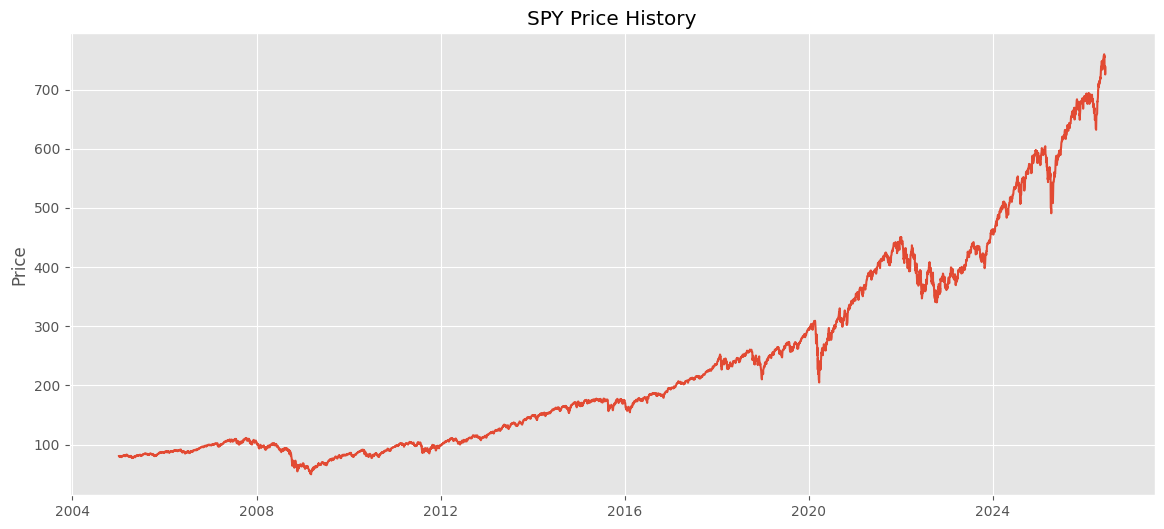

In [5]:
plt.figure(figsize=(14,6))

plt.plot(
    spy.index,
    spy["Close"]
)

plt.title("SPY Price History")
plt.ylabel("Price")
plt.show()

## Comments

Several major drops are visible throughout the sample, I assume these are things like Global Financial Crisis (2008), COVID Crash (2020), Inflation Shock (2022). These periods coincide with significant macroeconomic shocks and are likely associated with elevated volatility. And these are exactly the situations where we need enhanced forecasting models


We can see the market behaviour is not constant through time. Maybe we will need to use some fancy forecasting models in the project. 

# Experiment 2: Daily Return Dynamics

Now lets see how do daily returns behave through time.

We know asset prices are generally non-stationary because they exhibit long term trends. So we analyse returns which are close to stationary. 

The daily log return CAN defined as

$$ r_t = ln(P_t / P_{t-1}) $$

Returns are the fundamental input into almost every volatility forecasting model. So let me just visualise the dynamics before I start trying to forecast volatility. 

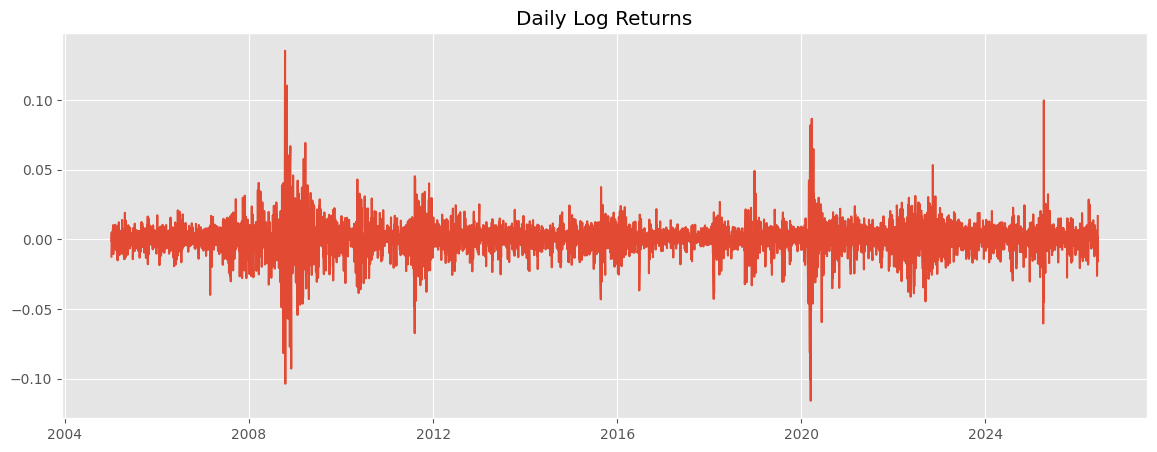

In [6]:
plt.figure(figsize=(14,5))

plt.plot(
    spy.index,
    spy["returns"]
)

plt.title("Daily Log Returns")
plt.show()

## Interpretation

Returns fluctuate around zero and show no obvious trend. However, large shocks appear concentrated in specific periods. This suggests that market risk changes over time rather than remaining constant.The clustering of extreme observations hints at the existence of volatility regimes, let's remember that

# Experiment 3: Distribution of Returns

Think about Black Scholes model, like BS, many classical finance models assume returns are normally distributed so it is best to check if returns follow normal distribution too. 

If returns deviate significantly from normality, these models may underestimate tail risk. So it is best we nderstand the return distribution to manage our risk

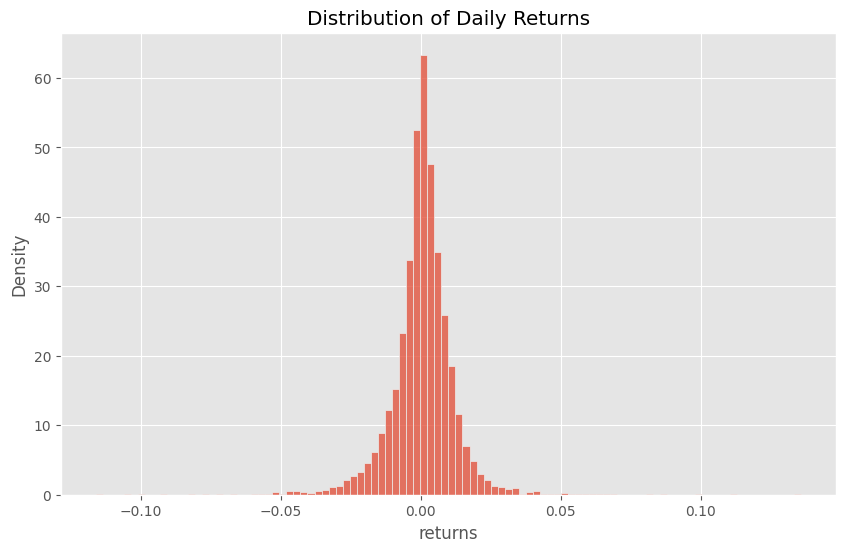

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    spy["returns"],
    bins=100,
    stat="density"
)

plt.title("Distribution of Daily Returns")
plt.show()

In [8]:
# compute statistics

stats = pd.DataFrame(
    {
        "Mean":[spy["returns"].mean()],
        "Std":[spy["returns"].std()],
        "Skew":[skew(spy["returns"])],
        "Kurtosis":[kurtosis(spy["returns"])]
    }
)

stats

,Mean,Std,Skew,Kurtosis
0,0.000409,0.011954,-0.304862,14.692653


## Comments: 

- Mean : The average daily return is close to zero.

- Volatility : Returns exhibit substantial dispersion around the mean.

- Skewness : Negative skewness implies downside moves tend to be larger than upside moves.

- Kurtosis : Positive excess kurtosis indicates fat tails. Extreme events occur more frequently than predicted by a Gaussian distribution. 

# Experiment 4: Comparison with a Gaussian Benchmark

If returns were Gaussian, extreme market crashes would be extremely rare. Empirical finance repeatedly finds that markets exhibit much heavier tails, I've personally seen this in many of my projects too. This experiment visually compares observed returns against a fitted normal distribution.

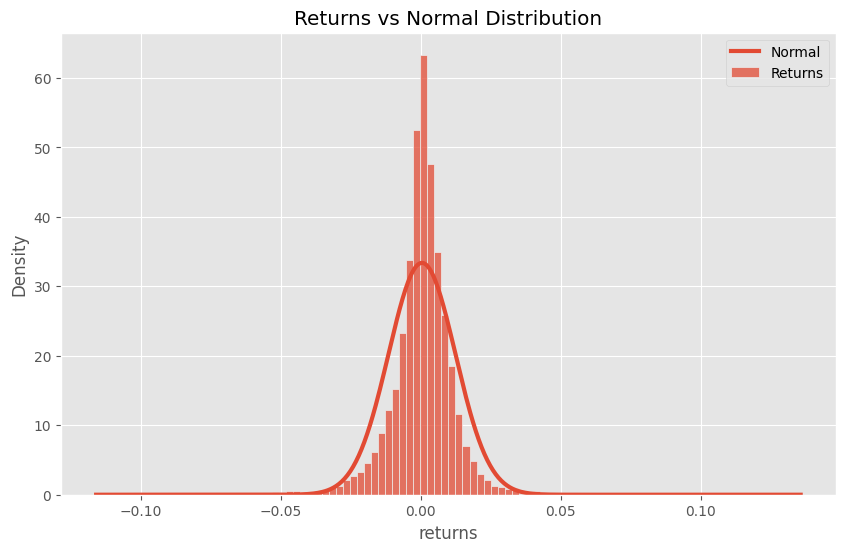

In [9]:
from scipy.stats import norm

x = np.linspace(
    spy["returns"].min(),
    spy["returns"].max(),
    500
)

mu = spy["returns"].mean()
sigma = spy["returns"].std()

plt.figure(figsize=(10,6))

sns.histplot(
    spy["returns"],
    bins=100,
    stat="density",
    label="Returns"
)

plt.plot(
    x,
    norm.pdf(x, mu, sigma),
    linewidth=3,
    label="Normal"
)

plt.legend()
plt.title("Returns vs Normal Distribution")
plt.show()

## Comments

The empirical distribution exhibits much fatter tails than the Gaussian benchmark. This means extreme events occur more frequently than standard models predict.

This is why risk forecasting is difficult and we need volatility models which adapt.

# Experiment 5: Volatility Clustering

At this point we'd like to study everything about volatility so we can model it better. Let's try to see if huge markets moves tend to happen together, because theory claims so.

Theoretical name for this phenomenon is Volatility Clustering. It says large movements tend to be followed by large movements and mall movements tend to be followed by small movements.

This basically mmeans volatility possesses memory.

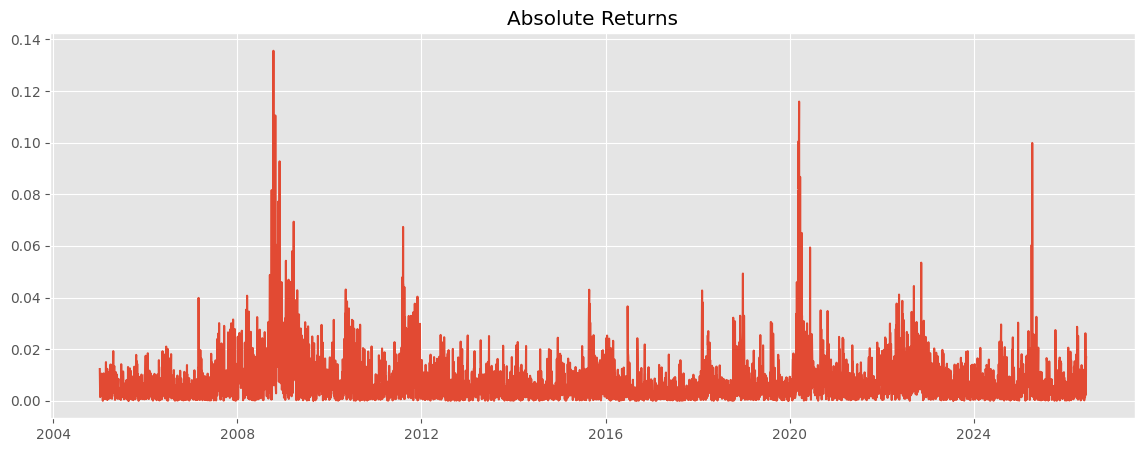

In [10]:
spy["abs_returns"] = spy["returns"].abs()

plt.figure(figsize=(14,5))

plt.plot(
    spy.index,
    spy["abs_returns"]
)

plt.title("Absolute Returns")
plt.show()

## Comments

The clustering behaviour is clearly visible. Once volatility is high, it stays high for a while. Like the shocks periods i mentioned, 2008 or COVID, we can see high volatility for while. 

# Experiment 6: Squared Returns as a Volatility Proxy

Volatility itself is not directly observable. A common proxy is squared returns. So high squared returns indicate high volatility periods. So let's see the dynamics of squared returns. 



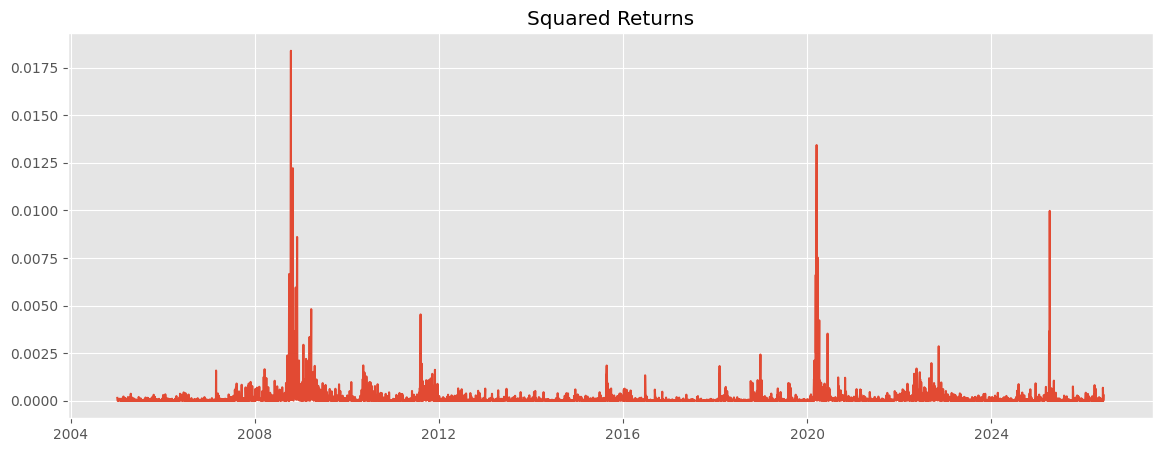

In [11]:
spy["squared_returns"] = spy["returns"]**2

plt.figure(figsize=(14,5))

plt.plot(
    spy.index,
    spy["squared_returns"]
)

plt.title("Squared Returns")
plt.show()

## Comments

The squared return also display long periods of elevated activity. And these periods persist through time rather than occurring randomly. This suggests that volatility possesses strong temporal dependence.

# Experiment 7: Realized Volatility

Lets now try to see how volatility evolves through time. 

Realized volatility is constructed using historical returns. Throughout this project it serves as the forecasting target.

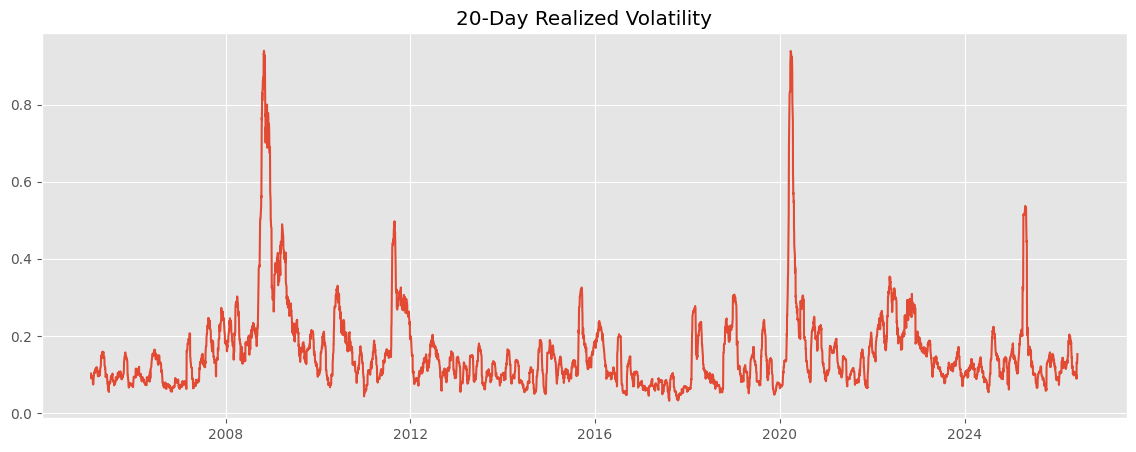

In [12]:
spy["vol_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

plt.figure(figsize=(14,5))

plt.plot(
    spy.index,
    spy["vol_20"]
)

plt.title("20-Day Realized Volatility")
plt.show()

## Comments

Volatility exhibits huge spikes during crisis periods. But more importantly, these spikes decay slowly. This suggests that our volatility forecast model should incorporate recent market information.

## Experiment 8 : Autocorrelation of returns 

Since we see this persistence, wwe must see if current returns can be predicted from past ones. Theoretically under weak form market efficiency, returns should exhibit little autocorrelation. If significant autocorrelation exists, predictable trading opportunities may be present.

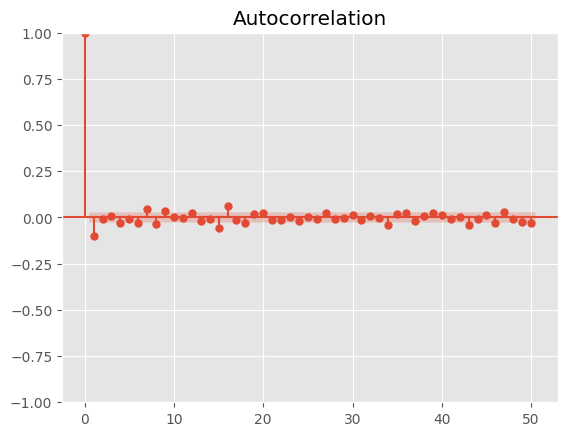

In [13]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    spy["returns"],
    lags=50
)

plt.show()

## Comments

Return autocorrelations are generally close to zero. This result is consistent with theory. Predicting returns directly appears difficult. However, volatility may still be predictable, which motivates the remainder of this project.

## Experiment 9 : Autocorrelation of Squared Errors

# Experiment 9: Volatility Persistence

While returns themselves may be uncorrelated, volatility often displays strong persistence. A standard diagnostic is the autocorrelation function of squared returns.

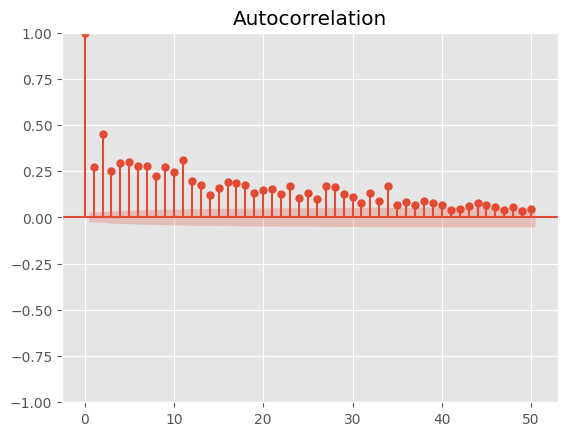

In [14]:
plot_acf(
    spy["returns"]**2,
    lags=50
)

plt.show()

## Comments

The autocorrelation function remains significantly positive across many lags. This indicates that volatility is highly persistent. So we might want to look at a model which explicitly models volatility dynamics using past squared returns and past volatility estimates.

# Experiment 10: Implied versus Realized Volatility

Let's finally try to see how does market implied volatility track realized volatility. The VIX measures the market's expectation of future volatility implied by option prices. Realized volatility measures volatility that actually occurred. The difference between the two is known as the Volatility Risk Premium.

In [15]:
vix = vix[["Close"]]

combined = pd.concat(
    [
        spy["vol_20"],
        vix["Close"]
    ],
    axis=1
)

combined.columns = [
    "RealizedVol",
    "VIX"
]

combined = combined.dropna()

/var/folders/k_/46tpgq_j2wzd3fm92b4v41_c0000gn/T/ipykernel_95830/648674301.py:3: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  combined = pd.concat(


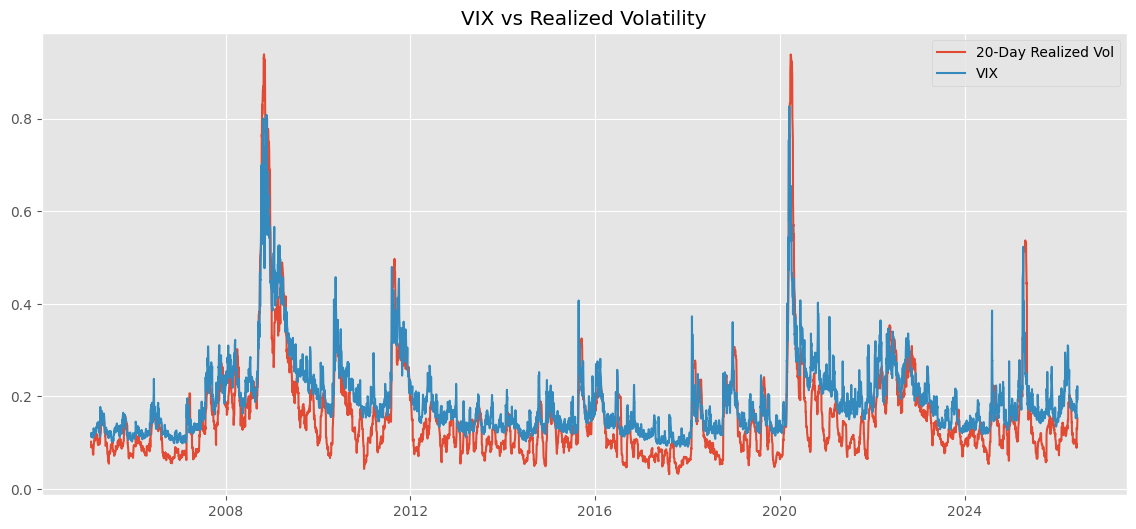

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    combined.index,
    combined["RealizedVol"],
    label="20-Day Realized Vol"
)

plt.plot(
    combined.index,
    combined["VIX"]/100,
    label="VIX"
)

plt.legend()
plt.title("VIX vs Realized Volatility")

plt.show()

## Comments

VIX and realized volatility move closely together. However, VIX frequently remains above realized volatility. This suggests that investors are willing to pay a premium for downside protection. The volatility risk premium will be discussed more in subsequent notebooks.